In [ ]:
'''
현재까지의 진행 상황:
    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고
    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.

그러나 이것만을 위해서 LangGraph를 사용하는 것은 아니며,
조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.

오늘은 retrieve 후에 query와 연관도를 체크하고
연관도가 떨어진다고 판단될 때 query를 rewrite 하는 conditional edge를 추가해보려고 한다.
'''

'\n현재까지의 진행 상황:\n    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고\n    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.\n\n그러나 이것만을 위해서 LangGraph를 사용하는 것은 아니며,\n조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.\n\n오늘은 retrieve 후에 query와 연관도를 체크하고\n연관도가 떨어진다고 판단될 때 query를 rewrite 하는 conditional edge를 추가해보려고 한다.\n'

In [ ]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

In [ ]:
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,                # chunk_size 고려해서 조정 - 추후 context history까지 관리해야 함
        'fetch_k': 50,          # 나중엔 동적 k / 히스토리 요약으로 구현하고 싶음
        'lamda_mult': 0.6       # simility와 가까운 수준(mmr에서)
    }
)

In [ ]:
from langchain_anthropic import ChatAnthropic
from langsmith import Client


client = Client()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [ ]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [ ]:
def retrieve(state: AgentState):
    query  = state['query']         # state의 query를 받아서 
    docs = retriever.invoke(query)  # retrieve 하고
    return {'context': docs}        # 그걸 context에 넣어서 toss~

In [ ]:
from typing import Literal

relevance_check_prompt = client.pull_prompt('langchain-ai/rag-document-relevance')


def doc_relevance_check(state: AgentState) -> Literal['generate', 'rewrite']:   # 앞으로 많이 보게 될 typehint 스타일
    context = state['context']
    query = state['query']
    doc_relevance_chain = relevance_check_prompt | llm
    response = doc_relevance_chain.invoke({'documents': context, 'question': query})

    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


rewrite_prompt = PromptTemplate.from_template("""
당신은 한국 세법 전문가입니다.
사용자의 질문을 소득세법 문서 검색에 최적화된 형태로 다시 작성하세요.

규칙:
1. 일상 용어를 법률 용어로 변환 (예: 월급 → 근로소득)
2. 모호한 표현을 구체화
3. 검색에 필요한 핵심 키워드 포함

예시:
    소득 관련
    '월급, 급여 -> 근로소득',
    '집 팔 때 세금, 부동산 양도 -> 양도소득세',
    '이자, 배당 -> 금융소득',
    '프리랜서 수입, 외주 -> 사업소득',
    '강연료, 원고료 -> 기타소득',
    
    공제 관련
    '부양가족 공제 -> 인적공제',
    '카드 공제 -> 신용카드 소득공제',
    '의료비 공제 -> 의료비 세액공제',
    
    일반 표현
    '세금 돌려받기 -> 환급',
    '세금 신고 -> 확정신고',
    '직장인 연말 세금 -> 연말정산'

원본 질문: {query}
Retrieve 최적화된 질문:
""")


def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 법률 용어에 적합하게 변경

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 변경된 질문을 포함하는 state를 반환
    """
    
    query = state['query']  # state에서 사용자의 질문 추출
    
    # rewrite 체인을 구성 프롬프트, LLM, 출력 파서 연결
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    # query 변경
    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  # 변경된 질문을 포함하는 state 반환

In [ ]:
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response} 

In [ ]:
# 아래 구조를 보면서 template 내용에 접근
generate_prompt.messages[0].prompt.template

"You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"

In [ ]:
'''
ChatPromptTemplate(
    input_variables=['context', 'question'],
    input_types={},
    partial_variables={},
    metadata={
        'lc_hub_owner': 'rlm',
        'lc_hub_repo': 'rag-prompt',
        'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'
    },
    messages=[
        HumanMessagePromptTemplate(
            prompt=PromptTemplate(
                input_variables=['context', 'question'],
                input_types={},
                partial_variables={},
                template="""
                    You are an assistant for question-answering tasks. 
                    Use the following pieces of retrieved context to answer the question. 
                    If you don't know the answer, just say that you don't know. 
                    Use three sentences maximum and keep the answer concise.
                    
                    Question: {question} 
                    Context: {context} 
                    Answer:
                """
            ),
            additional_kwargs={}
        )
    ]
)
'''

'\nChatPromptTemplate(\n    input_variables=[\'context\', \'question\'],\n    input_types={},\n    partial_variables={},\n    metadata={\n        \'lc_hub_owner\': \'rlm\',\n        \'lc_hub_repo\': \'rag-prompt\',\n        \'lc_hub_commit_hash\': \'50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e\'\n    },\n    messages=[\n        HumanMessagePromptTemplate(\n            prompt=PromptTemplate(\n                input_variables=[\'context\', \'question\'],\n                input_types={},\n                partial_variables={},\n                template="""\n                    You are an assistant for question-answering tasks. \n                    Use the following pieces of retrieved context to answer the question. \n                    If you don\'t know the answer, just say that you don\'t know. \n                    Use three sentences maximum and keep the answer concise.\n                    \n                    Question: {question} \n                    Context: 

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [ ]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [ ]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', doc_relevance_check)    # 앞에 doc_relevance_check에 typehint
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [ ]:
graph = graph_builder.compile()

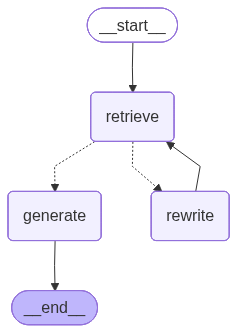

In [ ]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
query='연봉 5000만원인 사람의 산출세액은?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [ ]:
response['answer'].content

'연봉 5,000만원인 사람의 산출세액을 계산하려면 먼저 근로소득공제 등을 적용하여 과세표준을 구한 후 세율표를 적용해야 합니다. 제공된 세율표에 따르면, 과세표준이 1,400만원 초과 5,000만원 이하인 경우 "84만원 + (1,400만원을 초과하는 금액의 15%)"로 계산됩니다. 다만 정확한 산출세액을 계산하려면 근로소득공제, 인적공제 등 각종 공제사항이 적용된 과세표준 금액이 필요합니다.'

In [ ]:
from IPython.display import Markdown, display

display(Markdown(response['answer'].content))

연봉 5,000만원인 사람의 산출세액을 계산하려면 먼저 근로소득공제 등을 적용하여 과세표준을 구한 후 세율표를 적용해야 합니다. 제공된 세율표에 따르면, 과세표준이 1,400만원 초과 5,000만원 이하인 경우 "84만원 + (1,400만원을 초과하는 금액의 15%)"로 계산됩니다. 다만 정확한 산출세액을 계산하려면 근로소득공제, 인적공제 등 각종 공제사항이 적용된 과세표준 금액이 필요합니다.

## 무한loop를 방지하기 위한 방법 - 